# Influence of Torsion

In [1]:
# Import settings and constants
import os   # module for interfacing with the underlying operating system
import sys  # module for interacting with the Python interpreter
parent_directory = os.path.join(os.path.dirname(os.getcwd()))
sys.path.append(parent_directory)
from settings import *

# Define name of directory where to save analyses and figures
FIGURES_DIRECTORY_PATH = os.getcwd()
BENDING_DATA_DIRECTORY_PATH = r"C:\Users\qa21944\Github\phd-jupyter-notebooks\notebooks\analyses\22_Optimization_of_the_CRM-like_Box_Beam_with_Curved_Skin"
BENDING_TORSION_DATA_DIRECTORY_PATH = r"C:\Users\qa21944\Github\phd-jupyter-notebooks\notebooks\analyses\23_Optimization_of_the_CRM-like_Box_Beam_under_Combined_Bending_and_Torsional_Load"

# Define the names of the loading cases
LOADING_CASES = ["Bending-only", "Bending-torsion"]

# Define scaling constants for units
LENGTH_SCALE_FACTOR = 1e-3  # scaling factor to convert lengths from mm to m
EIGENVALUE_SCALE_FACTOR = 1e3  # scaling factor to convert eigenvalues from N/mm to N/m

# Define optimization parameters constants 
OPTIMIZER_TOLERANCE = 1e-3

# Allow for interactive plots
%matplotlib widget

Define constants of the model.

In [2]:
import numpy as np  # module for numerical operations

L = 29.38e3  # [mm] wingbox length
W = 3.41e3  # [mm] wingbox width
H = 0.77e3  # [mm] wingbox height
H_A = H / 15  # [mm] skin arc height
H_S = H / 10  # [mm] stiffener height
no_stiffeners = 2  # number of stiffeners
stiffeners_x_locations = np.linspace(0, W, no_stiffeners + 2)[
    1:-1
]  # [mm] stiffeners x-coordinates
stiffeners_spacing = W / (no_stiffeners + 1)  # [mm] stiffeners spacing
ribs_spacing = stiffeners_spacing * 1.4  # [mm] ribs spacing
no_ribs = round(L / ribs_spacing) + 1  # number of ribs
ribs_y_locations = np.linspace(0, L, no_ribs)  # [mm] ribs y-coordinates

## Mesh Convergence Study and Verification

Plot mesh convergence study results.

Degrees of freedom:  [   24516    50436    85860   192348   359964   790668  1777788  3990276
  8902980 19807308]
Linear buckling loads:  [43672.828 41132.539 40342.793 39820.    39705.828 39650.137 39611.043
 39612.906 39603.742 39598.391]
Percentage differences:  [10.289  3.874  1.88   0.56   0.271  0.131  0.032  0.037  0.014  0.   ]


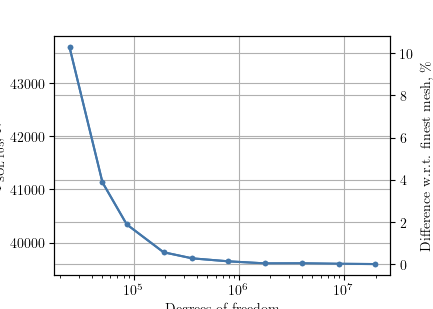

In [3]:
from pyNastran.op2.op2 import read_op2  # import function to read op2 file

# Import helper module for meshing
main_directory = os.path.join(os.path.dirname(os.path.dirname(os.getcwd())))
sys.path.append(main_directory)
from resources import box_beam_utils

# Define shell elements' lengths to be used for the mesh convergence study and print them to screen
target_element_lengths = np.geomspace(H / 2, H_S / 8, 10)  # [m]

# Initialize arrays with number of elements, number of degrees of freedom and linear buckling loads
dofs = np.empty(np.shape(target_element_lengths), dtype=int)
linear_buckling_loads = np.empty(np.shape(target_element_lengths))

# Iterate through the different target element lengths
for count, element_length in enumerate(target_element_lengths):
    # Generate mesh
    mesh = box_beam_utils.mesh_reinforced_box_beam_with_curved_skins(
        width=W,
        height=H,
        arc_height=H_A,
        ribs_y_coordinates=ribs_y_locations,
        stiffeners_x_coordinates=stiffeners_x_locations,
        stiffeners_height=H_S,
        element_length=element_length,
    )
    nodes_connectivity_matrix = mesh.faces.reshape(-1, 5)[:, 1:]

    # Read op2 file
    input_name = f"sol_105_{len(nodes_connectivity_matrix)}_elements"
    op2_filepath = os.path.join(
        BENDING_TORSION_DATA_DIRECTORY_PATH, input_name + ".op2"
    )
    sol_105_op2 = read_op2(op2_filename=op2_filepath, load_geometry=True, debug=None)

    # Find number of degrees of freedom and critical buckling load
    constrained_nodes_ids = next(iter(sol_105_op2.spcs.values()))[0].node_ids
    dofs[count] = (len(sol_105_op2.nodes) - len(constrained_nodes_ids)) * 6
    linear_buckling_loads[count] = sol_105_op2.eigenvectors[SECOND_SUBCASE_ID].eigrs[0]

# Plot buckling loads vs degrees of freedom with a log scale along the x-axis
fig, ax1 = plt.subplots(
    figsize=(TEXTWIDTH_INCHES * 0.7, TEXTWIDTH_INCHES * 0.5)
)  # create a figure and set of axes
buckling_load_line = ax1.semilogx(dofs, linear_buckling_loads, "o-")

# Create a twin set of axes to plot percentage difference vs degrees of freedom
ax2 = ax1.twinx()
percentage_diff = (linear_buckling_loads / linear_buckling_loads[-1] - 1) * 100
percentage_diff_line = ax2.plot(dofs, percentage_diff, "o-")

# Print degrees of freedom, linear buckling loads and percentage differences to screen
np.set_printoptions(precision=3, suppress=True)
print("Degrees of freedom: ", dofs)
print("Linear buckling loads: ", linear_buckling_loads)
print("Percentage differences: ", percentage_diff)

# Set axes labels and grid
ax1.set_xlabel("Degrees of freedom")
ax1.set_ylabel("$P_\mathrm{SOL\,105}$, N")
ax2.set_ylabel("Difference w.r.t. finest mesh, \%")
ax1.grid(True)
ax2.grid(True)

# Show plot and save figure
plt.show()
fig.savefig(
    os.path.join(FIGURES_DIRECTORY_PATH, "MeshConvergence.pdf"),
    bbox_inches="tight",
    pad_inches=0,
)

Plot critical buckling mode of converged mesh.

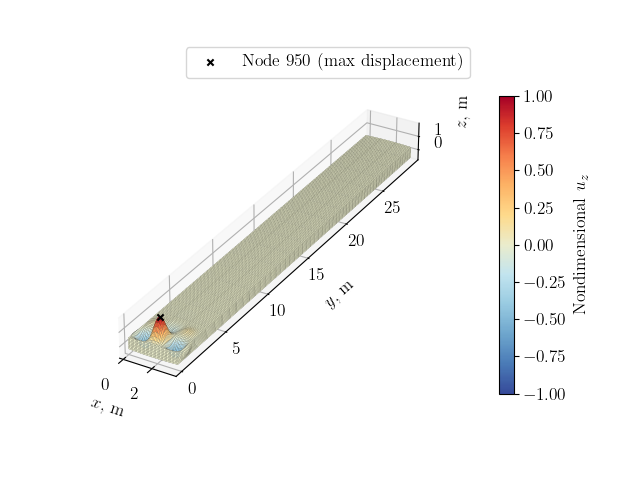

In [4]:
from resources import plot_utils


# Define function to adjust axes ticks and labels' position
def adjust_3d_plot(axes, colorbar=None):
    axes.locator_params(axis="x", nbins=3)  # set number of ticks of x-axis
    axes.locator_params(axis="z", nbins=2)  # set number of ticks of z-axis
    axes.tick_params(
        axis="y", which="major", pad=25
    )  # adjust position of ticks' label of y-axis
    axes.tick_params(
        axis="z", which="major", pad=6
    )  # adjust position of ticks' label of z-axis
    axes.yaxis.labelpad = 90  # adjust position of y-axis's label
    axes.zaxis.labelpad = 10  # adjust position of z-axis's label
    if colorbar is not None:
        colorbar.ax.set_position(
            colorbar.ax.get_position().shrunk(1.0, 0.62)
        )  # decrease colorbar size
        colorbar.ax.set_position(
            colorbar.ax.get_position().translated(-0.07, 0.18)
        )  # move colorbar upwards


# Plot buckling mode
plt.rcParams.update({"font.size": DEFAULT_FONT_SIZE / 0.8, "lines.markersize": 8})
input_name = f"sol_105_33120_elements"
op2_filepath = os.path.join(BENDING_TORSION_DATA_DIRECTORY_PATH, input_name + ".op2")
sol_105_op2_initial = read_op2(
    op2_filename=op2_filepath, load_geometry=True, debug=None
)
amplification_factor = 1.5  # amplification factor for displacements
clim = [-1, 1]  # colorbar limits
fig, ax, cbar = plot_utils.plot_eigenvector(
    op2=sol_105_op2_initial,
    subcase_id=SECOND_SUBCASE_ID,
    displacement_component="tz",
    colormap="sunset",
    length_unit="m",
    displacement_amplification_factor=amplification_factor,
    unit_scale_factor=LENGTH_SCALE_FACTOR,
    clim=clim,
)

# Plot node where maximum displacement occurs
root_node_id = plot_utils.plot_max_displacement_node(
    axes=ax,
    op2=sol_105_op2_initial,
    displacement_amplification_factor=amplification_factor,
    unit_scale_factor=LENGTH_SCALE_FACTOR,
)
ax.legend(bbox_to_anchor=(0.93, 0.92))

# Adjust plot and show it
adjust_3d_plot(ax, cbar)
plt.show()

# Save figure
BBOX_COLORBAR = fig.bbox_inches.from_bounds(
    0.8, 0.5, 5.2, 3.9
)  # create bounding box for figure
fig.savefig(
    os.path.join(FIGURES_DIRECTORY_PATH, f"InitialCriticalBucklingMode.png"),
    bbox_inches=BBOX_COLORBAR,
    pad_inches=0,
)

# Restore default sizes
plt.rcParams.update(
    {"font.size": DEFAULT_FONT_SIZE, "lines.markersize": DEFAULT_MARKER_SIZE}
)

Plot mesh convergence verification.

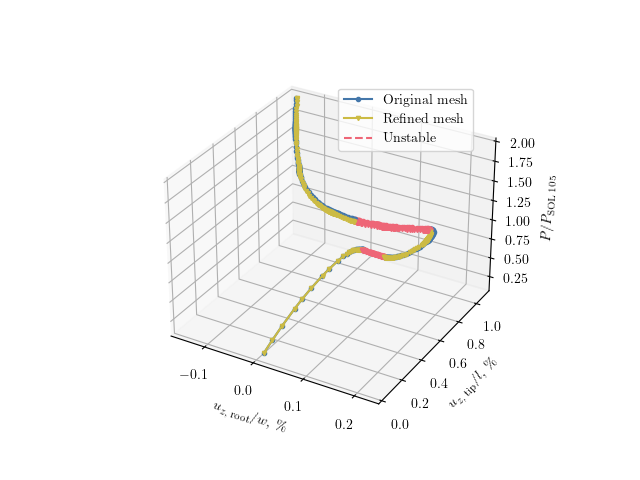

In [5]:
from resources import pynastran_utils

# Define dictionary with names of input files
input_name_dict = {"Original mesh": "33120_elements", "Refined mesh": "108276_elements"}

# Initialize dictionaries to store ids of nodes where max displacement occurs and tip nodes
tip_node_xyz = np.array([W / 2, L, 0])  # [mm] tip node coordinates
root_node_id_dict = {}  # dictionary to store ids of nodes where max displacement occurs
tip_node_id_dict = {}  # dictionary to store ids of tip nodes

# Initialize dictionaries to store eigenvalues and nondimensional loads and displacements
design_load = 39820.0  # [N]
eigenvalues_dict = {}  # dictionary to store eigenvalues
nondimensional_loads_dict = {}  # dictionary to store nondimensional loads
nondimensional_displacements_dict = (
    {}
)  # dictionary to store nondimensional displacements

# Create 3D plot of equilibrium diagram
fig = plt.figure()  # create a figure
ax_3d = plt.axes(projection="3d")  # create 3D axes
stable_lines = []  # list to store proxy artists for the legend
unstable_line = Line2D([0], [0], linestyle="--", color=UNSTABLE_COLOR, label="Unstable")

# Iterate over the different meshes
for count, key in enumerate(input_name_dict):
    # Read op2 file of linear buckling analysis
    op2_filepath = os.path.join(
        BENDING_TORSION_DATA_DIRECTORY_PATH, f"sol_105_{input_name_dict[key]}.op2"
    )
    sol_105_op2 = read_op2(op2_filename=op2_filepath, load_geometry=True, debug=None)

    # Find node where max displacement occurs
    max_displacement_index = np.argmax(
        np.linalg.norm(
            sol_105_op2.eigenvectors[SECOND_SUBCASE_ID].data[0, :, 0:3], axis=1
        )
    )  # find index of max displacement magnitude
    root_node_id_dict[key] = sol_105_op2.eigenvectors[SECOND_SUBCASE_ID].node_gridtype[
        max_displacement_index, 0
    ]  # find id of node with max displacement magnitude

    # Find tip node id
    nodes_xyz_array = np.array(
        [node.xyz for node in sol_105_op2.nodes.values()]
    )  # get nodes' coordinates
    tip_node_id_dict[key] = (
        np.argmin(np.linalg.norm(nodes_xyz_array - tip_node_xyz, axis=1)) + 1
    )  # find id of tip node

    # Read op2 file of nonlinear analysis
    op2_filepath = os.path.join(
        BENDING_TORSION_DATA_DIRECTORY_PATH, f"sol_106_{input_name_dict[key]}.op2"
    )
    sol_106_op2 = read_op2(op2_filename=op2_filepath, load_geometry=True, debug=None)

    # Read load-displacement history
    _, loads, displacements = pynastran_utils.read_load_displacement_history_from_op2(
        op2=sol_106_op2, node_ids=[root_node_id_dict[key], tip_node_id_dict[key]]
    )

    # Read eigenvalues
    f06_filepath = os.path.join(
        BENDING_TORSION_DATA_DIRECTORY_PATH, f"sol_106_{input_name_dict[key]}.f06"
    )  # path of f06 file
    eigenvalues_dict[key] = pynastran_utils.read_kllrh_lowest_eigenvalues_from_f06(
        f06_filepath
    )  # read eigenvalues from f06 file

    # Nondimensionalize loads and displacements
    nondimensional_loads_dict[key] = loads[FIRST_SUBCASE_ID][:, Z_INDEX] / design_load
    nondimensional_displacements_dict[key] = {
        "root": displacements[root_node_id_dict[key]][FIRST_SUBCASE_ID][:, Z_INDEX] / W,
        "tip": displacements[tip_node_id_dict[key]][FIRST_SUBCASE_ID][:, Z_INDEX] / L,
    }

    # Plot load-displacement curve
    plot_utils.plot_3d_load_displacements_stability(
        axes=ax_3d,
        displacements1=nondimensional_displacements_dict[key]["root"] * 100,
        displacements2=nondimensional_displacements_dict[key]["tip"] * 100,
        loads=nondimensional_loads_dict[key],
        eigenvalues=eigenvalues_dict[key],
        marker=MARKERS[count],
        color=COLORS[count],
    )
    stable_lines.append(
        Line2D(
            [0],
            [0],
            linestyle="-",
            marker=MARKERS[count],
            color=COLORS[count],
            label=key,
        )
    )  # create proxy artist for the legend

# Add proxy artist for unstable lines and create legend
fig.legend(handles=stable_lines + [unstable_line], bbox_to_anchor=(0.75, 0.83))

# Set axes labels and grid
ax_3d.set_xlabel("$u_{z,\,\mathrm{root}}/w$, \%")
ax_3d.set_ylabel("$u_{z,\,\mathrm{tip}}/l$, \%")
ax_3d.set_zlabel("$P/P_\mathrm{SOL\,105}$")
ax_3d.grid(visible=True)

# Show plot and save figure
plt.show()
bounding_box = fig.bbox_inches.from_bounds(
    1.4, 0.4, 4.3, 3.7
)  # create bounding box for figure
fig.savefig(
    os.path.join(FIGURES_DIRECTORY_PATH, "MeshConvergenceVerification.pdf"),
    bbox_inches=bounding_box,
    pad_inches=0,
)

Compare linear buckling load and nonlinear critical load between bending-only and bending-torsional load.

In [6]:
from pyNastran.op2.op2 import read_op2

no_elements = 33120  # number of elements
directory_paths = [BENDING_DATA_DIRECTORY_PATH, BENDING_TORSION_DATA_DIRECTORY_PATH]

# Read linear buckling loads
linear_buckling_loads = np.zeros(2)
for i, path in enumerate(directory_paths):
    op2_filepath = os.path.join(path, f"sol_105_{no_elements}_elements.op2")
    sol_105_op2 = read_op2(op2_filename=op2_filepath, load_geometry=True, debug=None)
    linear_buckling_loads[i] = sol_105_op2.eigenvectors[SECOND_SUBCASE_ID].eigrs[0]

# Compare linear buckling loads
print(
    f"""Linear buckling loads:
- Bending: {linear_buckling_loads[0]:.0f} N
- Bending and torsion: {linear_buckling_loads[1]:.0f} N
Percentage difference: {(linear_buckling_loads[1] / linear_buckling_loads[0] - 1) * 100:.2f} %\n"""
)

# Read nonlinear critical loads
nonlinear_critical_loads = np.zeros(2)
for i, path in enumerate(directory_paths):
    op2_filepath = os.path.join(path, f"sol_106_{no_elements}_elements.op2")
    sol_106_op2 = read_op2(op2_filename=op2_filepath, load_geometry=True, debug=None)
    _, loads, _ = pynastran_utils.read_load_displacement_history_from_op2(
        op2=sol_106_op2
    )
    f06_filepath = os.path.join(path, f"sol_106_{no_elements}_elements.f06")
    eigenvalues = pynastran_utils.read_kllrh_lowest_eigenvalues_from_f06(f06_filepath)
    first_negative_eigenvalue_index = np.where(eigenvalues[0] < 0)[0][0]
    nonlinear_critical_loads[i] = loads[FIRST_SUBCASE_ID][
        first_negative_eigenvalue_index, Z_INDEX
    ]

# Compare nonlinear critical loads
print(
    f"""Nonlinear critical loads:
- Bending: {nonlinear_critical_loads[0]:.0f} N
- Bending and torsion: {nonlinear_critical_loads[1]:.0f} N
Percentage difference: {(nonlinear_critical_loads[1] / nonlinear_critical_loads[0] - 1) * 100:.2f} %"""
)

Linear buckling loads:
- Bending: 39823 N
- Bending and torsion: 39820 N
Percentage difference: -0.01 %

Nonlinear critical loads:
- Bending: 44018 N
- Bending and torsion: 43754 N
Percentage difference: -0.60 %


## Linear Buckling Optimization

Plot linear buckling optimization results.

Requested variables at last iteration:
- interp.t_cp: [7.902 1.439]
- nastran_solver.ks_buckling: [0.004]
- nastran_solver.ks_stress: [-392.827]
- nastran_solver.mass: [4.013]
Requested variables at last iteration:
- interp.t_cp: [7.905 1.51 ]
- nastran_solver.ks_buckling: [0.001]
- nastran_solver.ks_stress: [-392.5]
- nastran_solver.mass: [4.045]


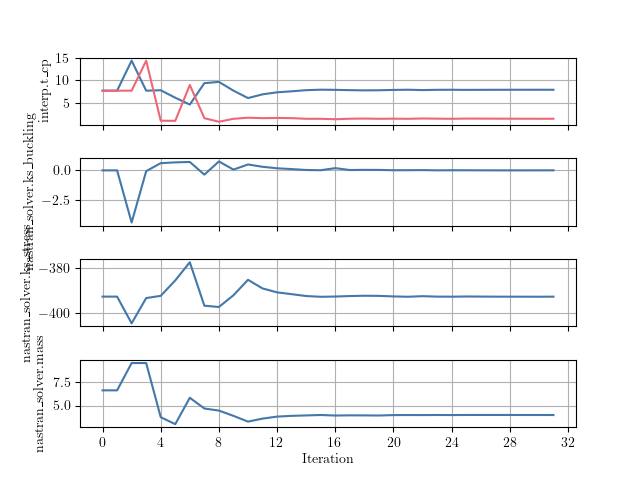

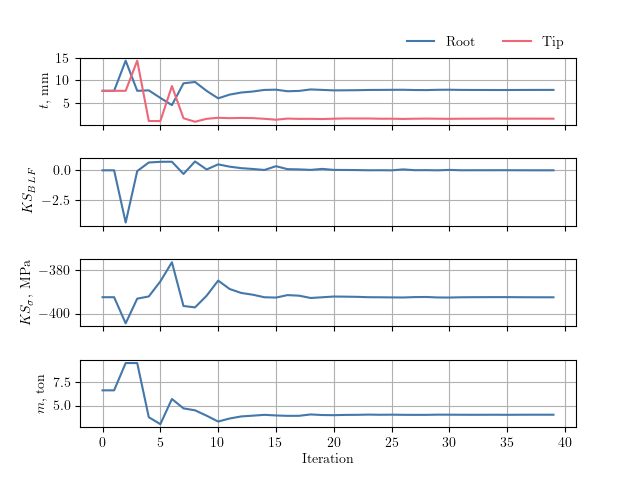

In [7]:
from resources import optimization_utils


# Read and plot linear buckling optimization history for bending-only case
recorder_filename = "sol_105_curved_linear_opt.sql"
recorder_filepath = os.path.join(BENDING_DATA_DIRECTORY_PATH, recorder_filename)
_, _, bending_only_linear_opt_histories = optimization_utils.plot_optimization_history(
    recorder_filepath
)

# Read and plot linear buckling optimization history for bending and torsion case
recorder_filename = "sol_105_linear_opt.sql"
recorder_filepath = os.path.join(BENDING_TORSION_DATA_DIRECTORY_PATH, recorder_filename)
y_labels = ["$t$, mm", "$KS_{BLF}$", "$KS_\sigma$, MPa", "$m$, ton"]
fig, axes, bending_torsion_linear_opt_histories = (
    optimization_utils.plot_optimization_history(recorder_filepath, y_labels=y_labels)
)

# Add legend to thickness plot
axes[0].legend(
    ["Root", "Tip"],
    loc="upper right",
    bbox_to_anchor=(1.0, 1.5),
    ncol=2,
    frameon=False,
)

# Save figure
fig.savefig(
    os.path.join(FIGURES_DIRECTORY_PATH, "LinearOptHistories.pdf"),
    bbox_inches="tight",
    pad_inches=0,
)

Plot bar chart of linearly optimized thicknesses.

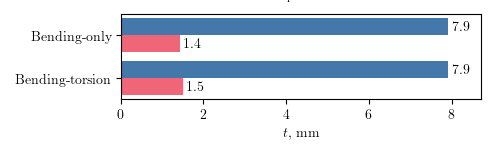

In [8]:
# Define function to plot bar chart of final thicknesses
def plot_thickness_bar_chart(
    bending_only_histories,
    bending_torsion_histories,
    figure_filename,
    iter_indices=[-1, -1],
):
    # Set up data for the bar chart
    optimizations = tuple(LOADING_CASES)
    final_thicknesses = {
        "$t_\mathrm{root}$": (
            bending_only_histories["interp.t_cp"][iter_indices[0], 0],
            bending_torsion_histories["interp.t_cp"][iter_indices[1], 0],
        ),
        "$t_\mathrm{tip}$": (
            bending_only_histories["interp.t_cp"][iter_indices[0], 1],
            bending_torsion_histories["interp.t_cp"][iter_indices[1], 1],
        ),
    }

    # Plot bar chart with final thicknesses
    y_pos = np.arange(len(optimizations))  # the label locations
    height = 0.4  # the height of the bars
    multiplier = 0.5  # multiplier to separate bars
    fig, ax = plt.subplots(
        figsize=(TEXTWIDTH_INCHES * 0.8, TEXTWIDTH_INCHES * 0.25)
    )  # create figure and axis
    for (
        attribute,
        values,
    ) in final_thicknesses.items():  # iterate over attributes and values
        offset = height * multiplier  # offset to separate bars
        rects = ax.barh(y_pos + offset, values, height, label=attribute)  # plot bars
        ax.bar_label(rects, padding=3, fmt="{:,.1f}")  # add labels to bars
        multiplier += 1.0  # increase multiplier to separate bars

    # Add some text for labels, title and custom x-axis tick labels, etc.
    ax.set_xlabel("$t$, mm")
    ax.invert_yaxis()  # labels read top-to-bottom
    ax.set_yticks(y_pos + height, optimizations)
    ax.set_xlim(
        right=max(max(v) for v in final_thicknesses.values()) + 0.8
    )  # set limits of x-axis

    # Save figure
    plt.tight_layout()  # ensures proper spacing between subplots
    ax.legend(
        bbox_to_anchor=(0.03, 1.01), ncols=2, frameon=False
    )  # add legend after tight layout
    plt.show()
    fig.savefig(
        os.path.join(FIGURES_DIRECTORY_PATH, figure_filename + ".pdf"),
        bbox_inches="tight",
        pad_inches=0,
    )


# Plot bar chart with final thicknesses
figure_name = "LinearOptThicknesses"
plot_thickness_bar_chart(
    bending_only_linear_opt_histories, bending_torsion_linear_opt_histories, figure_name
)

Plot bar chart of linearly optimized masses.

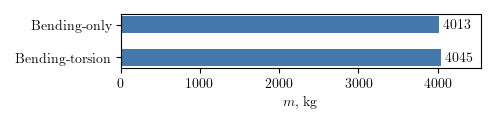

Percentage difference: 0.79 %


In [9]:
# Define function to plot bar chart of final thicknesses
def plot_final_mass_bar_chart(
    bending_only_histories,
    bending_torsion_histories,
    figure_filename,
    iter_indices=[-1, -1],
):

    # Find final masses of curved and flat skin model
    design_labels = tuple(LOADING_CASES)
    final_masses = np.array(
        [
            bending_only_histories["nastran_solver.mass"][iter_indices[0], 0],
            bending_torsion_histories["nastran_solver.mass"][iter_indices[1], 0],
        ]
    )

    # Make bar chart
    fig, ax = plt.subplots(figsize=(TEXTWIDTH_INCHES * 0.8, TEXTWIDTH_INCHES * 0.2))
    y_pos = np.arange(len(design_labels))  # position of bars
    p = ax.barh(y_pos, final_masses * 1e3, height=0.5)  # plot bars
    ax.bar_label(p, padding=3, fmt="{:.0f}")  # add labels to bars
    ax.set_yticks(y_pos, labels=design_labels)  # set labels of y-axis
    ax.invert_yaxis()  # labels read top-to-bottom
    ax.set_xlabel("$m$, kg")  # set label of x-axis
    ax.set_xlim(right=np.max(final_masses) * 1e3 + 500)  # set limits of x-axis

    # Save figure
    plt.tight_layout()  # ensures proper spacing between subplots
    plt.show()
    fig.savefig(
        os.path.join(FIGURES_DIRECTORY_PATH, figure_filename + ".pdf"),
        bbox_inches="tight",
        pad_inches=0,
    )

    # Print percentage difference
    print(f"Percentage difference: {(final_masses[1]/final_masses[0] - 1)*100:.2f} %")


# Plot bar chart with final thicknesses
figure_name = "LinearOptMasses"
plot_final_mass_bar_chart(
    bending_only_linear_opt_histories, bending_torsion_linear_opt_histories, figure_name
)

Compare critical buckling mode of linearly optimized structures.

Critical buckling mode of structure optimized with bending-only loading:


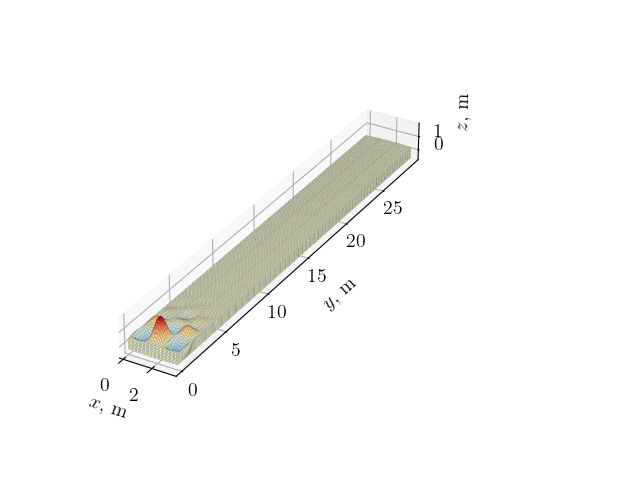

Critical buckling mode of structure optimized with bending-torsion loading:


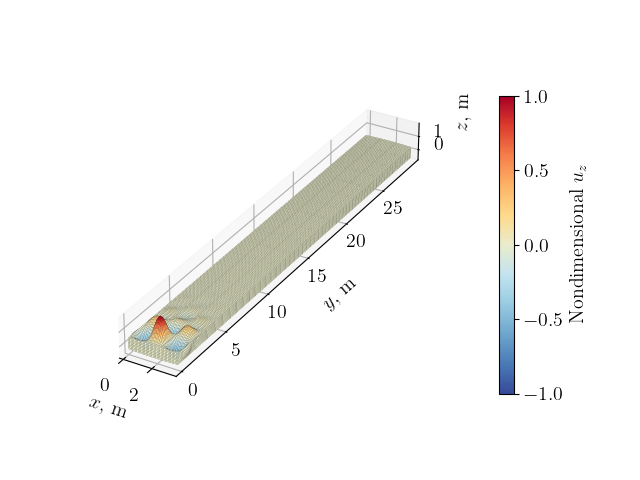

In [10]:
# Define amplification factor of displacements
amplification_factor = 1.5

# Plot critical buckling mode of model with bending-only loading
print(
    f"Critical buckling mode of structure optimized with {LOADING_CASES[0].lower()} loading:"
)
clim = [-1.0, 1.0]
op2_filepath = os.path.join(
    BENDING_DATA_DIRECTORY_PATH, "sol_105_curved_linear_opt.op2"
)
sol_105_op2 = read_op2(op2_filename=op2_filepath, load_geometry=True, debug=None)
plt.rcParams.update({"font.size": DEFAULT_FONT_SIZE * (1 / 0.7)})
fig, ax, cbar = plot_utils.plot_eigenvector(
    op2=sol_105_op2,
    subcase_id=SECOND_SUBCASE_ID,
    displacement_component="tz",
    colormap="sunset",
    displacement_amplification_factor=amplification_factor,
    unit_scale_factor=LENGTH_SCALE_FACTOR,
    clim=clim,
)

# Adjust plot and show it
cbar.remove()
adjust_3d_plot(ax, cbar)
plt.show()

# Save figure
BBOX_NO_COLORBAR = fig.bbox_inches.from_bounds(
    0.8, 0.5, 4.0, 3.9
)  # create bounding box for figure
fig.savefig(
    os.path.join(
        FIGURES_DIRECTORY_PATH, f"LinearOptBucklingMode-{LOADING_CASES[0]}.png"
    ),
    bbox_inches=BBOX_NO_COLORBAR,
    pad_inches=0,
)

# Plot critical buckling mode of model with bending-torsion loading
print(
    f"Critical buckling mode of structure optimized with {LOADING_CASES[1].lower()} loading:"
)
op2_filepath = os.path.join(
    BENDING_TORSION_DATA_DIRECTORY_PATH, "sol_105_linear_opt.op2"
)
sol_105_op2_linear_opt = read_op2(
    op2_filename=op2_filepath, load_geometry=True, debug=None
)
fig, ax, cbar = plot_utils.plot_eigenvector(
    op2=sol_105_op2_linear_opt,
    subcase_id=SECOND_SUBCASE_ID,
    displacement_component="tz",
    colormap="sunset",
    displacement_amplification_factor=amplification_factor,
    unit_scale_factor=LENGTH_SCALE_FACTOR,
    clim=clim,
)

# Adjust plot and show it
adjust_3d_plot(ax, cbar)
plt.show()

# Save figure
fig.savefig(
    os.path.join(
        FIGURES_DIRECTORY_PATH, f"LinearOptBucklingMode-{LOADING_CASES[1]}.png"
    ),
    bbox_inches=BBOX_COLORBAR,
    pad_inches=0,
)

# Reset default sizes
plt.rcParams.update({"font.size": DEFAULT_FONT_SIZE})

Compare nonlinear load-displacement diagrams of linearly optimized structures.

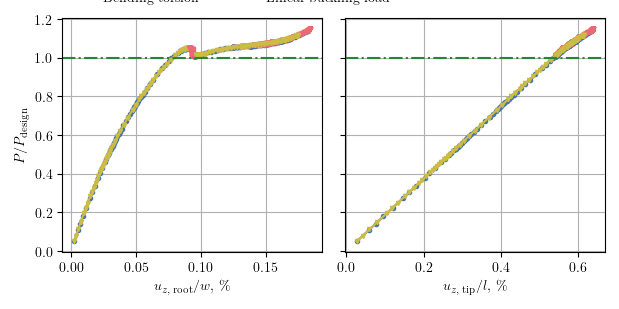

In [11]:
# Find ids of tip nodes and add to dictionary of plot nodes
tip_node_xyz = np.array([W / 2, L, 0])  # tip node is taken at the center of the tip rib
tip_node_id = (
    np.argmin(
        np.linalg.norm(
            np.array([sol_105_op2.nodes[i].xyz for i in sol_105_op2.nodes])
            - tip_node_xyz,
            axis=1,
        )
    )
    + 1  # argmin finds index of the node, add 1 to get id
)

# Define list with ids of nodes to plot
plot_nodes_ids = [root_node_id, tip_node_id]

# Define list with names of input files
input_names = ["sol_106_curved_linear_opt", "sol_106_linear_opt"]


# Define function to plot load-displacement diagram
def plot_load_displacement_diagram(
    input_names, plot_nodes_ids, load_factor_multiplier=1
):
    # Create one figure with two subplots side by side
    fig, axes = plt.subplots(
        1, 2, sharey=True, figsize=(TEXTWIDTH_INCHES, TEXTWIDTH_INCHES * 0.5)
    )
    stable_lines = []

    # Initialize dictionaries to store eigenvalues, OP2 objects, and nondimensional loads
    eigenvalues_dict = {}
    sol_106_op2_dict = {}
    nondimensional_loads_dict = {}

    # Iterate over the two linearly optimized structures
    for i, key in enumerate(LOADING_CASES):

        # Read eigenvalues
        f06_path = os.path.join(
            directory_paths[i], input_names[i] + ".f06"
        )  # path to .f06 file
        eigenvalues_dict[key] = pynastran_utils.read_kllrh_lowest_eigenvalues_from_f06(
            f06_path
        )

        # Read load and displacement histories
        sol_106_op2_dict[key] = read_op2(
            os.path.join(directory_paths[i], input_names[i] + ".op2"),
            load_geometry=True,
            debug=None,
        )
        load_factors, _, displacements = (
            pynastran_utils.read_load_displacement_history_from_op2(
                op2=sol_106_op2_dict[key], node_ids=plot_nodes_ids
            )
        )
        nondimensional_loads_dict[key] = (
            load_factors[FIRST_SUBCASE_ID] * load_factor_multiplier
        )

        # Plot applied load vs root displacement
        plot_utils.plot_2d_load_displacements_stability(
            axes[0],
            displacements[plot_nodes_ids[0]][FIRST_SUBCASE_ID][:, Z_INDEX] / W * 100,
            nondimensional_loads_dict[key],
            eigenvalues_dict[key],
            MARKERS[i],
            COLORS[i],
        )
        stable_lines.append(
            Line2D(
                [0],
                [0],
                linestyle="-",
                marker=MARKERS[i],
                color=COLORS[i],
                label=key,
            )
        )

        # Plot applied load vs tip displacement
        plot_utils.plot_2d_load_displacements_stability(
            axes[1],
            displacements[plot_nodes_ids[1]][FIRST_SUBCASE_ID][:, Z_INDEX] / L * 100,
            nondimensional_loads_dict[key],
            eigenvalues_dict[key],
            MARKERS[i],
            COLORS[i],
        )

    # Return
    return (
        fig,
        axes,
        stable_lines,
        eigenvalues_dict,
        sol_106_op2_dict,
        nondimensional_loads_dict,
    )


# Plot load-displacement diagrams
(
    fig,
    axes,
    stable_lines,
    eigenvalues_dict,
    sol_106_op2_dict,
    nondimensional_loads_dict,
) = plot_load_displacement_diagram(
    input_names, plot_nodes_ids, load_factor_multiplier=2
)


# Plot linear buckling load lines
for ax in axes:
    ax.axhline(y=1.0, color=GLASS_CEILING_COLOR, linestyle="-.")

# Create proxy artists for linear buckling load line
glass_ceiling_line = Line2D(
    [0], [0], linestyle="-.", color=GLASS_CEILING_COLOR, label="Linear buckling load"
)

# Set plot appearance for the first subplot
axes[0].set_xlabel("$u_{z,\,\mathrm{root}}/w$, \%")
axes[0].set_ylabel("$P/P_\mathrm{design}$")
axes[0].grid(visible=True)

# Set plot appearance for the second subplot
axes[1].set_xlabel("$u_{z,\,\mathrm{tip}}/l$, \%")
axes[1].grid(visible=True)

# Save figure
plt.tight_layout()  # Ensures proper spacing between subplots
axes[0].legend(
    handles=stable_lines + [unstable_line, glass_ceiling_line],
    loc="upper left",
    ncols=2,
    bbox_to_anchor=(-0.04, 1.25),
    frameon=False,
)  # add legend after tight_layout
plt.show()
fig.savefig(
    os.path.join(FIGURES_DIRECTORY_PATH, "LinearOptLoadDisplacement.pdf"),
    bbox_inches="tight",
    pad_inches=0,
)

Compare nonlinear critical load.

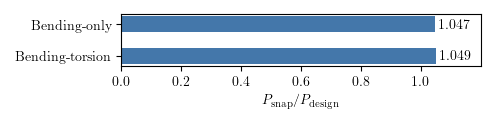

Percentage difference: 0.18 %


In [12]:
def plot_nonlinear_critical_load_bar_chart(
    key_list, eigenvalues_dict, nondimensional_loads_dict, figure_name
):
    # Find limit point load for each analysis
    first_negative_eigenvalue_index_dict = {}
    nonlinear_critical_loads = np.zeros(len(key_list))
    for i, key in enumerate(key_list):
        first_negative_eigenvalue_index_dict[key] = np.where(
            eigenvalues_dict[key][0] < 0
        )[0][
            0
        ]  # find index of first negative eigenvalue
        nonlinear_critical_loads[i] = np.mean(
            nondimensional_loads_dict[key][
                first_negative_eigenvalue_index_dict[key]
                - 1 : first_negative_eigenvalue_index_dict[key]
                + 1
            ]
        )  # calculate nondimensional applied load at limit point as the mean between the last stable and first unstable load

    # Plot bar chart with limit point loads
    fig, ax = plt.subplots(figsize=(TEXTWIDTH_INCHES * 0.8, TEXTWIDTH_INCHES * 0.2))
    y_pos = np.arange(len(key_list))  # position of bars
    p = ax.barh(y_pos, nonlinear_critical_loads, height=0.5)  # plot bars
    ax.bar_label(p, padding=3, fmt="{:,.3f}")  # add labels to bars
    ax.set_yticks(y_pos, labels=tuple(key_list))  # set labels of y-axis
    ax.invert_yaxis()  # labels read top-to-bottom
    ax.set_xlabel("$P_\mathrm{snap}/P_\mathrm{design}$")  # set label of x-axis
    ax.set_xlim(right=np.max(nonlinear_critical_loads) + 0.15)  # set limits of x-axis

    # Save figure
    plt.tight_layout()  # Ensures proper spacing between subplots
    plt.show()
    fig.savefig(
        os.path.join(FIGURES_DIRECTORY_PATH, figure_name + ".pdf"),
        bbox_inches="tight",
        pad_inches=0,
    )

    # Print percentage difference
    print(
        f"Percentage difference: {(nonlinear_critical_loads[1]/nonlinear_critical_loads[0] - 1)*100:.2f} %"
    )


# Plot bar chart with limit point loads
plot_nonlinear_critical_load_bar_chart(
    LOADING_CASES,
    eigenvalues_dict,
    nondimensional_loads_dict,
    "NonlinearCriticalLoadBarChart",
)

Compare deformation at design load of linearly optimized structures.

Deformation of structure optimized under bending-only loading:


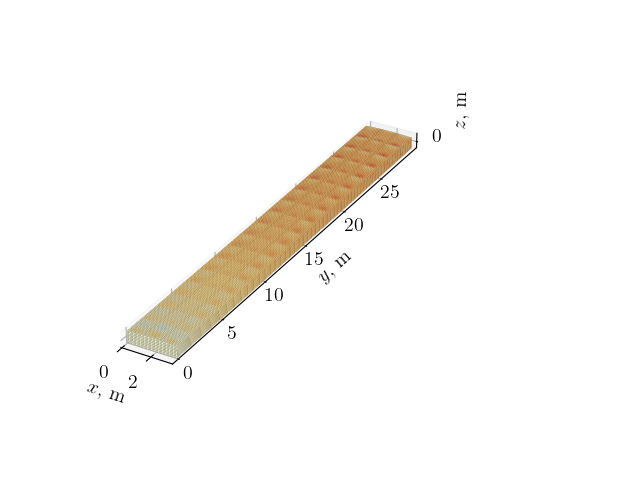

Deformation of structure optimized under bending-torsion loading:


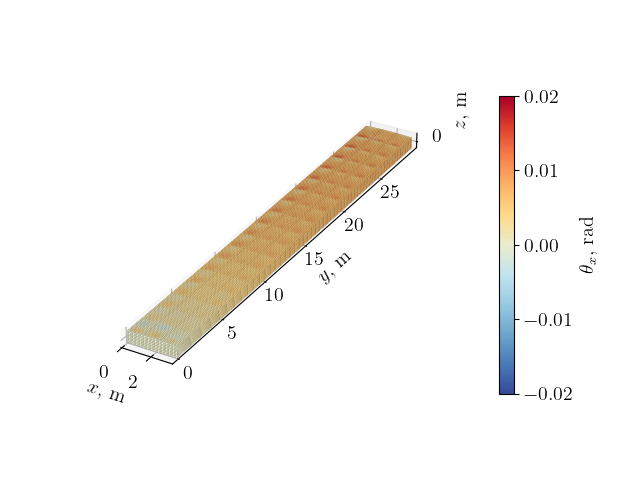

In [13]:
def plot_deformation_comparison(
    nondimensional_loads_dict, sol_106_op2_dict, clim, label
):
    # Plot deformation of linearly optimized structure
    print(
        f"Deformation of structure optimized under {LOADING_CASES[0].lower()} loading:"
    )
    increment_number = (
        np.argmin(np.abs(nondimensional_loads_dict[LOADING_CASES[0]] - 1)) + 1
    )  # find number of closest converged increment to design load
    plt.rcParams.update({"font.size": DEFAULT_FONT_SIZE * (1 / 0.7)})
    fig, ax, cbar = plot_utils.plot_deformation(
        op2=sol_106_op2_dict[LOADING_CASES[0]],
        subcase_id=FIRST_SUBCASE_ID,
        load_step=increment_number,
        displacement_component="rx",
        colormap="sunset",
        length_unit="m",
        unit_scale_factor=LENGTH_SCALE_FACTOR,
        clim=clim,
    )
    adjust_3d_plot(ax, cbar)
    ax.set_zticks([0])
    cbar.remove()
    plt.show()
    fig.savefig(
        os.path.join(
            FIGURES_DIRECTORY_PATH, f"{LOADING_CASES[0]}-{label}-deformation.png"
        ),
        bbox_inches=BBOX_NO_COLORBAR,
        pad_inches=0,
    )

    # Plot deformation of nonlinearly optimized structure
    print(
        f"Deformation of structure optimized under {LOADING_CASES[1].lower()} loading:"
    )
    increment_number = (
        np.argmin(np.abs(nondimensional_loads_dict[LOADING_CASES[1]] - 1)) + 1
    )  # find number of closest converged increment to design load
    fig, ax, cbar = plot_utils.plot_deformation(
        op2=sol_106_op2_dict[LOADING_CASES[1]],
        subcase_id=FIRST_SUBCASE_ID,
        load_step=increment_number,
        displacement_component="rx",
        colormap="sunset",
        length_unit="m",
        unit_scale_factor=LENGTH_SCALE_FACTOR,
        clim=clim,
    )
    adjust_3d_plot(ax, cbar)
    ax.set_zticks([0])
    plt.show()
    fig.savefig(
        os.path.join(
            FIGURES_DIRECTORY_PATH, f"{LOADING_CASES[1]}-{label}-deformation.png"
        ),
        bbox_inches=BBOX_COLORBAR,
        pad_inches=0,
    )

    # Restore default font size
    plt.rcParams.update({"font.size": DEFAULT_FONT_SIZE})


# # Plot deformation comparison
clim = [-0.02, 0.02]  # color limits for deformation plot
label = "linear-opt"
plot_deformation_comparison(nondimensional_loads_dict, sol_106_op2_dict, clim, label)

## Nonlinear Structural Stability Optimization

Compare thickness distribution.

Requested variables at last iteration:
- interp.t_cp: [7.758 1.237]
- nastran_solver.applied_load: [39532.512]
- nastran_solver.ks_stability: [2.825]
- nastran_solver.ks_stress: [-392.472]
- nastran_solver.mass: [3.865]
Requested variables at last iteration:
- interp.t_cp: [8.08  1.044]
- nastran_solver.ks_stability: [0.005]
- nastran_solver.ks_stress: [-414.176]
- nastran_solver.load_factor: [0.216]
- nastran_solver.mass: [3.92]


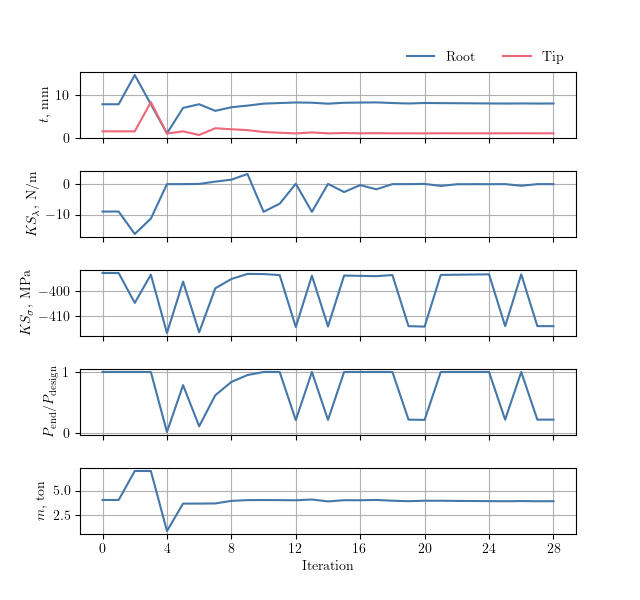

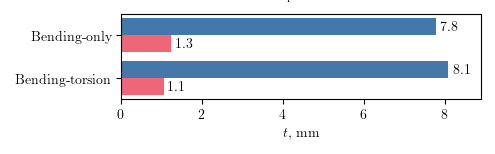

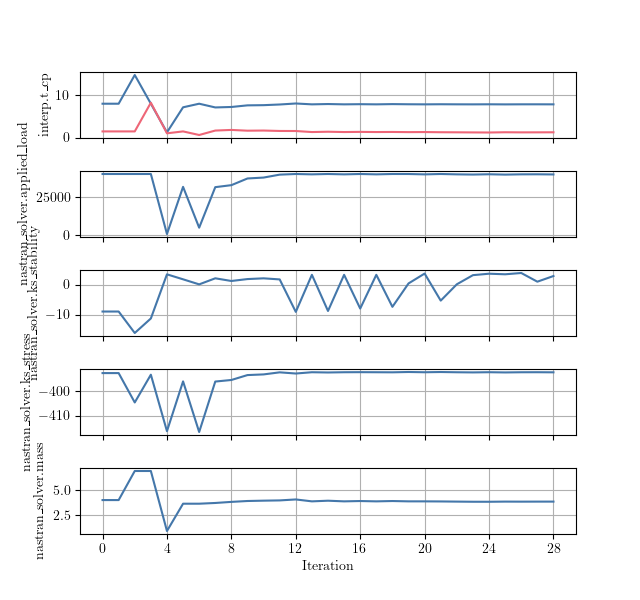

In [14]:
# Read and plot nonlinear structural stability optimization history for bending-only case
recorder_filename = "sol_106_curved_nonlinear_opt.sql"
recorder_filepath = os.path.join(BENDING_DATA_DIRECTORY_PATH, recorder_filename)
_, _, bending_only_nonlinear_opt_histories = (
    optimization_utils.plot_optimization_history(recorder_filepath)
)

# Find index of last feasible design
bending_only_feasible_design_index = np.where(
    bending_only_nonlinear_opt_histories["nastran_solver.ks_stability"][:, 0]
    <= OPTIMIZER_TOLERANCE
)[0][-1]

# Read and plot linear buckling optimization history for bending and torsion case
recorder_filename = "sol_105_linear_opt.sql"
recorder_filepath = os.path.join(BENDING_TORSION_DATA_DIRECTORY_PATH, recorder_filename)


# Read linear buckling optimization history for bending and torsion case
recorder_filename = "sol_106_nonlinear_opt.sql"
recorder_filepath = os.path.join(BENDING_TORSION_DATA_DIRECTORY_PATH, recorder_filename)
y_labels = ["$t$, mm", "$KS_\lambda$, N/m", "$KS_\sigma$, MPa", "$P_\mathrm{end}/P_\mathrm{design}$", "$m$, ton"]
fig, axes, bending_torsion_nonlinear_opt_histories = (
    optimization_utils.plot_optimization_history(recorder_filepath, y_labels=y_labels)
)

# # Replot load history in nondimensional form (P_end/P_design)
# axes[1].clear()  # clear previous plot
# iterations_array = np.arange(
#     bending_torsion_nonlinear_opt_histories["nastran_solver.applied_load"].shape[0]
# )
# axes[1].plot(
#     iterations_array,
#     bending_torsion_nonlinear_opt_histories["nastran_solver.applied_load"][:, 0]/design_load,
# )

# Add legend to thickness plot
axes[0].legend(
    ["Root", "Tip"],
    loc="upper right",
    bbox_to_anchor=(1.0, 1.5),
    ncol=2,
    frameon=False,
)

# Save figure
plt.show()
fig.savefig(
    os.path.join(FIGURES_DIRECTORY_PATH, "NonlinearOptHistories.pdf"),
    bbox_inches="tight",
    pad_inches=0,
)

# Find index of last feasible design
bending_torsion_feasible_design_index = np.where(
    bending_torsion_nonlinear_opt_histories["nastran_solver.ks_stability"][:, 0]
    <= OPTIMIZER_TOLERANCE
)[0][-1]

# Plot bar chart with final thicknesses
figure_name = "NonlinearOptThicknesses"
plot_thickness_bar_chart(
    bending_only_nonlinear_opt_histories,
    bending_torsion_nonlinear_opt_histories,
    figure_name,
    iter_indices=[
        bending_only_feasible_design_index,
        bending_torsion_feasible_design_index,
    ],
)

Compare optimized masses.

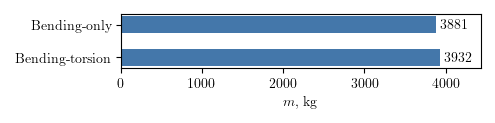

Percentage difference: 1.31 %
Percentage difference between masses resulting from linear and nonlinear optimizations:
- Bending-only: -3.29 %
- Bending-torsion: -2.80 %


In [15]:
# Plot bar chart with final thicknesses
figure_name = "NonlinearOptMasses"
plot_final_mass_bar_chart(
    bending_only_nonlinear_opt_histories,
    bending_torsion_nonlinear_opt_histories,
    figure_name,
    iter_indices=[
        bending_only_feasible_design_index,
        bending_torsion_feasible_design_index,
    ],
)

# Print percentage difference between masses resulting from linear and nonlinear optimizations
bending_only_mass_percentage_diff = (
    bending_only_nonlinear_opt_histories["nastran_solver.mass"][
        bending_only_feasible_design_index, 0
    ]
    / bending_only_linear_opt_histories["nastran_solver.mass"][-1, 0]
    - 1
) * 100
bending_torsion_mass_percentage_diff = (
    bending_torsion_nonlinear_opt_histories["nastran_solver.mass"][
        bending_torsion_feasible_design_index, 0
    ]
    / bending_torsion_linear_opt_histories["nastran_solver.mass"][-1, 0]
    - 1
) * 100
print(
    f"""Percentage difference between masses resulting from linear and nonlinear optimizations:
- Bending-only: {bending_only_mass_percentage_diff:.2f} %
- Bending-torsion: {bending_torsion_mass_percentage_diff:.2f} %"""
)

Compare twist along the length of the structure.

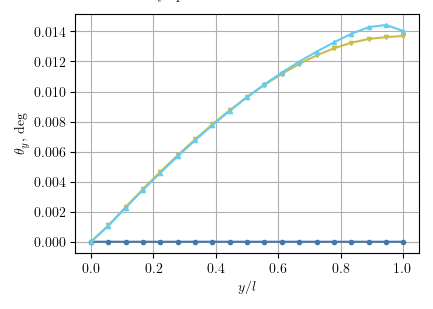

In [16]:
from resources import pynastran_utils


# Define function to calculate twist based on the vertical displacement of front and rear node of each rib
def calculate_twist(front_node_coord, front_node_disp, rear_node_coord, rear_node_disp):
    delta_theta = np.arctan(
        (
            (front_node_coord[Z_INDEX] + front_node_disp[Z_INDEX])
            - (rear_node_coord[Z_INDEX] + rear_node_disp[Z_INDEX])
        )
        / (
            (rear_node_coord[X_INDEX] + rear_node_disp[X_INDEX])
            - (front_node_coord[X_INDEX] + front_node_disp[X_INDEX])
        )
    ) - np.arctan(
        (front_node_coord[Z_INDEX] - rear_node_coord[Z_INDEX])
        / (rear_node_coord[X_INDEX] - front_node_coord[X_INDEX])
    )
    return delta_theta


# Read SOL 106 op2 file of nonlinearly optimized structure under bending and torsion loading
op2_filepath = os.path.join(
    BENDING_TORSION_DATA_DIRECTORY_PATH, "sol_106_nonlinear_opt_feasible.op2"
)
sol_106_op2_nonlinear_opt = read_op2(
    op2_filename=op2_filepath, load_geometry=True, debug=None
)

# Create dictionary with op2 objects of model under bending and torsion loading
twist_op2_dict = {
    "Initial - SOL 105": sol_105_op2_initial,
    "Linearly optimized - SOL 105": sol_105_op2_linear_opt,
    "Nonlinearly optimized - SOL 106": sol_106_op2_nonlinear_opt,
}

# Create figure with one subplots
fig, ax = plt.subplots(figsize=(TEXTWIDTH_INCHES * 0.7, TEXTWIDTH_INCHES * 0.5))

# Iterate over the op2 objects in the dictionary
for i, key in enumerate(twist_op2_dict):

    # Find coordinates of all nodes
    nodes_xyz = np.vstack([grid.xyz for grid in twist_op2_dict[key].nodes.values()])

    # Initialize arrays to store node coordinates and ids
    front_nodes_xyz = np.zeros((len(ribs_y_locations), 3))
    front_nodes_ids = np.zeros_like(ribs_y_locations, dtype=int)
    central_nodes_ids = np.zeros_like(ribs_y_locations, dtype=int)
    rear_nodes_ids = np.zeros_like(ribs_y_locations, dtype=int)
    rear_nodes_xyz = np.zeros((len(ribs_y_locations), 3))

    # Iterate over ribs
    for j, rib_y in enumerate(ribs_y_locations):

        # Find front node id
        front_nodes_xyz[j] = np.array([0, rib_y, H/2])
        front_nodes_ids[j] = (
            np.argmin(np.linalg.norm(nodes_xyz - front_nodes_xyz[j], axis=1)) + 1
        )

        # Find central node id
        central_node_xyz = np.array([W / 2, rib_y, H/2])
        central_nodes_ids[j] = (
            np.argmin(np.linalg.norm(nodes_xyz - central_node_xyz, axis=1)) + 1
        )

        # Find rear node id
        rear_nodes_xyz[j] = np.array([W, rib_y, H/2])
        rear_nodes_ids[j] = (
            np.argmin(np.linalg.norm(nodes_xyz - rear_nodes_xyz[j], axis=1)) + 1
        )

    # Read displacement data from OP2 object
    displacements = pynastran_utils.read_displacement_from_op2(
        op2=twist_op2_dict[key],
        node_ids=np.hstack([front_nodes_ids, central_nodes_ids, rear_nodes_ids]),
    )

    # Initialize array to store twist angles
    twist_angles = np.zeros_like(ribs_y_locations)

    # Iterate over ribs
    for j, rib_y in enumerate(ribs_y_locations):
        # Calculate twist angle from displacements of front and rear nodes
        twist_angles[j] = calculate_twist(
            front_nodes_xyz[j],
            displacements[front_nodes_ids[j]][FIRST_SUBCASE_ID],
            rear_nodes_xyz[j],
            displacements[rear_nodes_ids[j]][FIRST_SUBCASE_ID],
        )

    # Plot twist angles
    ax.plot(
        ribs_y_locations / L,
        np.degrees(twist_angles),
        label=key,
        color=COLORS[i],
        marker=MARKERS[i],
    )

# Set labels and grid
ax.set_ylabel(r"$\theta_y$, deg")
ax.grid(True)
ax.set_xlabel("$y/l$")

# Add legend after tight layout
fig.tight_layout()
fig.legend(bbox_to_anchor=(0.71, 1.2), frameon=False)

# Show and save plot
plt.show()
fig.savefig(
    os.path.join(FIGURES_DIRECTORY_PATH, "TwistComparison.pdf"),
    bbox_inches="tight",
    pad_inches=0,
)

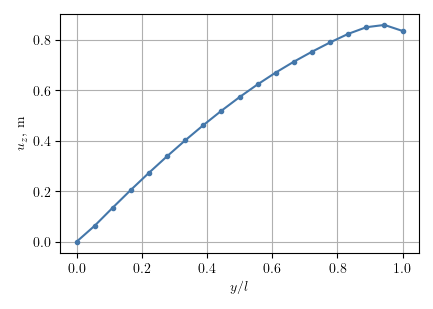

In [17]:
front_nodes_z_disp = np.zeros_like(ribs_y_locations)
rear_nodes_z_disp = np.zeros_like(ribs_y_locations)

# Iterate over ribs
for j, rib_y in enumerate(ribs_y_locations):
    front_nodes_z_disp[j] = displacements[front_nodes_ids[j]][FIRST_SUBCASE_ID][Z_INDEX]
    rear_nodes_z_disp[j] = displacements[rear_nodes_ids[j]][FIRST_SUBCASE_ID][Z_INDEX]

# Create figure with one subplots
fig, ax = plt.subplots(figsize=(TEXTWIDTH_INCHES * 0.7, TEXTWIDTH_INCHES * 0.5))

# Plot twist angles
ax.plot(
    ribs_y_locations / L,
    front_nodes_z_disp - rear_nodes_z_disp,
    label="Front spar",
    color=COLORS[0],
    marker=MARKERS[0],
)

# Set labels and grid
ax.set_ylabel("$u_{z}$, m")
ax.grid(True)
ax.set_xlabel("$y/l$")

# Add legend after tight layout
fig.tight_layout()
fig.legend(bbox_to_anchor=(0.71, 1.2), frameon=False)

# Show and save plot
plt.show()

Compare load-displacement diagrams.

Critical buckling load factor for bending-only: 0.69
Critical buckling load factor for bending-torsion: 0.40


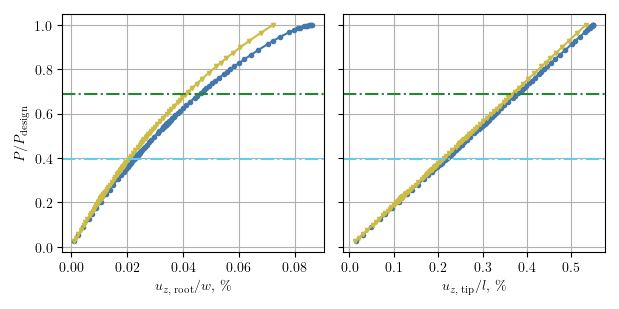

In [18]:
# Define list with names of SOL 106 input files
sol_106_input_names = ["sol_106_curved_nonlinear_opt", "sol_106_nonlinear_opt_feasible"]

# Plot load-displacement diagrams
(
    fig,
    axes,
    stable_lines,
    eigenvalues_dict,
    sol_106_op2_dict,
    nondimensional_loads_dict,
) = plot_load_displacement_diagram(sol_106_input_names, plot_nodes_ids)

# Define list with names of SOL 105 input files
sol_105_input_names = ["sol_105_curved_nonlinear_opt", "sol_105_nonlinear_opt"]

# Define list of colors for linear buckling load lines
glass_ceiling_colors = [GLASS_CEILING_COLOR, COLORS[2]]

# Initialize list to store linear buckling load lines
linear_buckling_load_lines = [Line2D([0], [0])] * 2

# Iterate over the two linearly optimized structures
sol_105_op2_dict = {}
for i, input_name in enumerate(sol_105_input_names):
    # Read linear buckling load
    op2_filepath = os.path.join(directory_paths[i], f"{input_name}.op2")
    sol_105_op2_dict[LOADING_CASES[i]] = read_op2(
        op2_filename=op2_filepath, load_geometry=True, debug=None
    )
    buckling_load_factor = (
        sol_105_op2_dict[LOADING_CASES[i]].eigenvectors[SECOND_SUBCASE_ID].eigrs[0]
    )
    print(
        f"Critical buckling load factor for {LOADING_CASES[i].lower()}: {buckling_load_factor:.2f}"
    )

    # Iterate over the two subplots
    for ax in axes:
        # Plot linear buckling load line
        linear_buckling_load_lines[i] = ax.axhline(
            y=buckling_load_factor,
            color=glass_ceiling_colors[i],
            linestyle="-.",
            label=f"{LOADING_CASES[i]} linear buckling load",
        )

# Set plot appearance for the first subplot
axes[0].set_xlabel("$u_{z,\,\mathrm{root}}/w$, \%")
axes[0].set_ylabel("$P/P_\mathrm{design}$")
axes[0].grid(visible=True)

# Set plot appearance for the second subplot
axes[1].set_xlabel("$u_{z,\,\mathrm{tip}}/l$, \%")
axes[1].grid(visible=True)

# Save figure
plt.tight_layout()  # Ensures proper spacing between subplots
axes[0].legend(
    handles=stable_lines + linear_buckling_load_lines,
    loc="upper left",
    ncols=2,
    bbox_to_anchor=(-0.04, 1.25),
    frameon=False,
)  # add legend after tight_layout
plt.show()
fig.savefig(
    os.path.join(FIGURES_DIRECTORY_PATH, "NonlinearOptLoadDisplacement.pdf"),
    bbox_inches="tight",
    pad_inches=0,
)

Compare critical buckling modes.

Critical buckling mode of structure optimized with bending-only loading:


c:\Users\qa21944\Github\phd-jupyter-notebooks\notebooks\resources\plot_utils.py:587: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure()


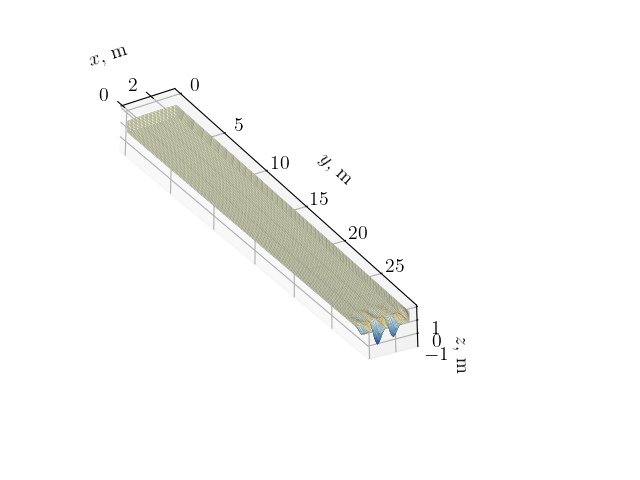

Critical buckling mode of structure optimized with bending-torsion loading:


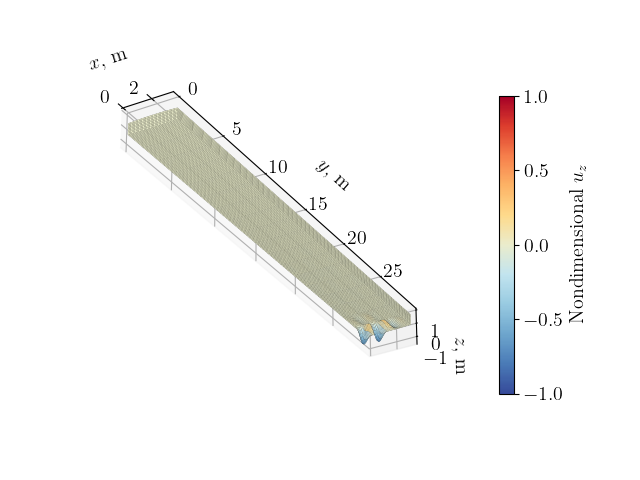

In [19]:
# Plot critical buckling mode of structure optimized with bending-only load
print(
    f"Critical buckling mode of structure optimized with {LOADING_CASES[0].lower()} loading:"
)
clim = [-1.0, 1.0]
plt.rcParams.update({"font.size": DEFAULT_FONT_SIZE * (1 / 0.7)})
fig, ax, cbar = plot_utils.plot_eigenvector(
    op2=sol_105_op2_dict[LOADING_CASES[0]],
    subcase_id=SECOND_SUBCASE_ID,
    displacement_component="tz",
    colormap="sunset",
    displacement_amplification_factor=amplification_factor,
    unit_scale_factor=LENGTH_SCALE_FACTOR,
    clim=clim,
)

# Adjust plot and show it
cbar.remove()
adjust_3d_plot(ax, cbar)
ax.view_init(-30, -60)
ax.tick_params(
    axis="y", which="major", pad=40
)  # adjust position of ticks' label of y-axis
plt.show()

# Save figure
fig.savefig(
    os.path.join(
        FIGURES_DIRECTORY_PATH, f"NonlinearOptBucklingMode-{LOADING_CASES[0]}.png"
    ),
    bbox_inches=BBOX_NO_COLORBAR,
    pad_inches=0,
)

# Plot critical buckling mode of model with curved skin
print(
    f"Critical buckling mode of structure optimized with {LOADING_CASES[1].lower()} loading:"
)
fig, ax, cbar = plot_utils.plot_eigenvector(
    op2=sol_105_op2_dict[LOADING_CASES[1]],
    subcase_id=SECOND_SUBCASE_ID,
    displacement_component="tz",
    colormap="sunset",
    displacement_amplification_factor=amplification_factor,
    unit_scale_factor=LENGTH_SCALE_FACTOR,
    clim=clim,
)

# Adjust plot and show it
adjust_3d_plot(ax, cbar)
ax.view_init(-30, -60)
ax.tick_params(
    axis="y", which="major", pad=40
)  # adjust position of ticks' label of y-axis
plt.show()

# Save figure
fig.savefig(
    os.path.join(
        FIGURES_DIRECTORY_PATH, f"NonlinearOptBucklingMode-{LOADING_CASES[1]}.png"
    ),
    bbox_inches=BBOX_COLORBAR,
    pad_inches=0,
)

# Reset default sizes
plt.rcParams.update({"font.size": DEFAULT_FONT_SIZE})

Compare eigenvalue diagram for feasible and unfeasible designs.

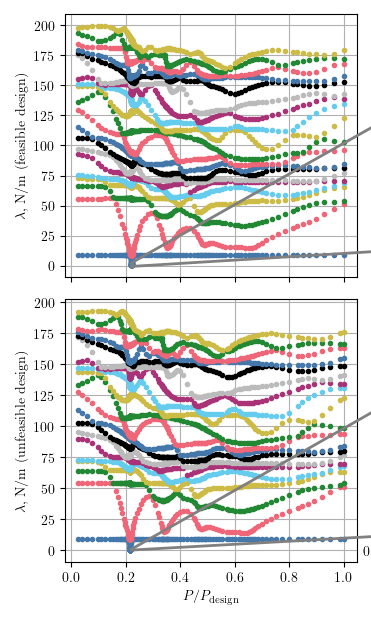

In [20]:
from mpl_toolkits.axes_grid1.inset_locator import mark_inset


# Create figure with two subplots
fig, axes = plt.subplots(
    2, 1, sharex=True, figsize=(TEXTWIDTH_INCHES*0.6, TEXTWIDTH_INCHES)
)

# Plot eigenvalue diagram of feasible design
key = LOADING_CASES[1]
plot_utils.plot_eigenvalue_diagram(
    loads=nondimensional_loads_dict[key],
    eigenvalues=eigenvalues_dict[key]*EIGENVALUE_SCALE_FACTOR,
    axes=axes[0])
axes[0].set_ylabel(f"$\lambda$, N/m (feasible design)")  # set y-axis label

# Read load history and eigenvalues for unfeasible design
op2_filepath = os.path.join(
    BENDING_TORSION_DATA_DIRECTORY_PATH, "sol_106_nonlinear_opt_unfeasible.op2"
)
sol_106_op2_unfeasible = read_op2(
    op2_filename=op2_filepath, load_geometry=True, debug=None
)
load_factors, _, _ = pynastran_utils.read_load_displacement_history_from_op2(
    op2=sol_106_op2_unfeasible)
first_subcase_key = next(iter(load_factors))
nondimensional_loads_unfeasible = load_factors[first_subcase_key]
eigenvalues_unfeasible = pynastran_utils.read_kllrh_lowest_eigenvalues_from_op2(
    op2=sol_106_op2_unfeasible)

# Plot eigenvalue diagram of unfeasible design
plot_utils.plot_eigenvalue_diagram(
    loads=nondimensional_loads_unfeasible,
    eigenvalues=eigenvalues_unfeasible*EIGENVALUE_SCALE_FACTOR,
    axes=axes[1])
axes[1].set_ylabel(f"$\lambda$, N/m (unfeasible design)")  # set y-axis label

# Finalize plot appearance
axes[1].set_xlabel("$P/P_\mathrm{design}$")
plt.tight_layout()

# Create zoomed inset in eigenvalue plot of feasible design
x1, x2 = 0.2204, 0.2215  # x-interval of interest for the first zoomed inset
y1, y2 = -0.5, 2.4  # y-interval of interest for the first zoomed inset
axin1 = axes[0].inset_axes([1.1, .1, 0.5, 0.5], xlim=(x1, x2), ylim=(y1, y2))
axin1.yaxis.tick_right()

# Plot in zoomed inset
plot_utils.plot_eigenvalue_diagram(
    loads=nondimensional_loads_dict[key],
    eigenvalues=eigenvalues_dict[key]*EIGENVALUE_SCALE_FACTOR,
    axes=axin1)

# Set zoomed inset appearance
axin1.grid(True)
mark_inset(axes[0], axin1, loc1=2, loc2=3, fc="none", ec="0.5", linewidth=2, zorder=2)

# Create zoomed inset in eigenvalue plot of feasible design
x1, x2 = 0.21545, 0.21559  # x-interval of interest for the first zoomed inset
y1, y2 = -0.01, 0.11  # y-interval of interest for the first zoomed inset
axin2 = axes[1].inset_axes([1.1, .1, 0.5, 0.5], xlim=(x1, x2), ylim=(y1, y2))
axin2.yaxis.tick_right()

# Plot in zoomed inset
plot_utils.plot_eigenvalue_diagram(
    loads=nondimensional_loads_unfeasible,
    eigenvalues=eigenvalues_unfeasible*EIGENVALUE_SCALE_FACTOR,
    axes=axin2)

# Set zoomed inset appearance
axin2.grid(True)
mark_inset(axes[1], axin2, loc1=2, loc2=3, fc="none", ec="0.5", linewidth=2, zorder=2)

# Show and save plot
plt.show()
fig.savefig(
    os.path.join(
        FIGURES_DIRECTORY_PATH, "EigenvalueDiagram.pdf"
    ),
    bbox_inches="tight",
    pad_inches=0,
)

Plot critical eigenvector for unfeasible design.

Nonlinear critical load factor: 0.22


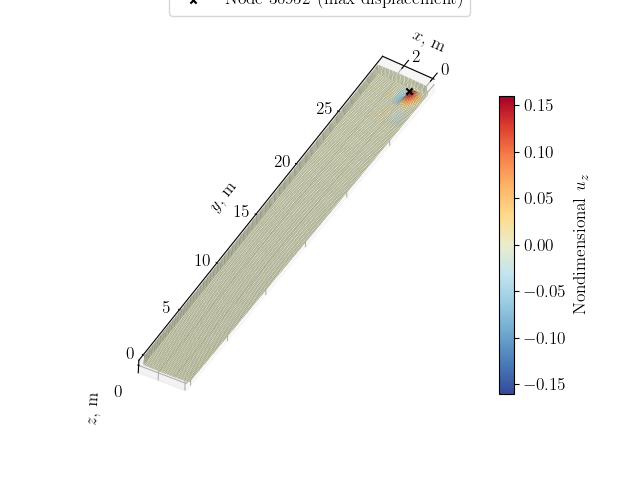

In [21]:
# Increase font size and markersize
plt.rcParams.update({"font.size": DEFAULT_FONT_SIZE / 0.8, "lines.markersize": 8})

# Find index of first negative eigenvalue and print nonlinear critical load factor
first_negative_eigenvalue_index = np.where(eigenvalues_unfeasible[0] < 0)[0][0]
nonlinear_critical_load = nondimensional_loads_unfeasible[first_negative_eigenvalue_index]
print(f"Nonlinear critical load factor: {nonlinear_critical_load:.2f}")

# Plot critical eigenvector
eigenvectors_key = next(iter(sol_106_op2_unfeasible.eigenvectors))
critical_eigenvector_number =\
    eigenvalues_unfeasible.shape[0]*first_negative_eigenvalue_index + 1
amplification_factor = 4
clim = [-.16, .16]
fig, ax, cbar = plot_utils.plot_eigenvector(
        op2=sol_106_op2_unfeasible, subcase_id=eigenvectors_key,
        eigenvector_number=critical_eigenvector_number,
        displacement_component='tz', colormap='sunset',
        unit_scale_factor=LENGTH_SCALE_FACTOR,
        displacement_amplification_factor=amplification_factor,
        clim=clim)

# Highlight node where max displacement occurs
max_disp_node_id = plot_utils.plot_max_displacement_node(
    axes=ax, op2=sol_106_op2_unfeasible, subcase_id=eigenvectors_key,
    eigenvector_number=critical_eigenvector_number,
    unit_scale_factor=LENGTH_SCALE_FACTOR,
    displacement_amplification_factor=amplification_factor)

# Add legend and adjust plot appearance
ax.legend(bbox_to_anchor=(0.93, 1.05))
adjust_3d_plot(ax, cbar)
ax.view_init(-45, 60)
ax.xaxis.labelpad = -8  # adjust position of y-axis's label
ax.tick_params(axis="x", which="major", pad=0)  # adjust position of ticks' label of y-axis
ax.tick_params(axis="y", which="major", pad=40)  # adjust position of ticks' label of y-axis
ax.set_zticks([0])  # set z-axis ticks to 0

# Show plot and save figure
plt.show()
bbox_colorbar_xl = fig.bbox_inches.from_bounds(
    0.8, 0.5, 5.2, 4.5
)
fig.savefig(
    os.path.join(FIGURES_DIRECTORY_PATH, f"UnfeasibleDesignCriticalEigenvector.png"),
    bbox_inches=bbox_colorbar_xl,
    pad_inches=0,
)

# Restore default sizes
plt.rcParams.update(
    {"font.size": DEFAULT_FONT_SIZE, "lines.markersize": DEFAULT_MARKER_SIZE}
)

Plot load-displacement diagram for maximum displacement node.

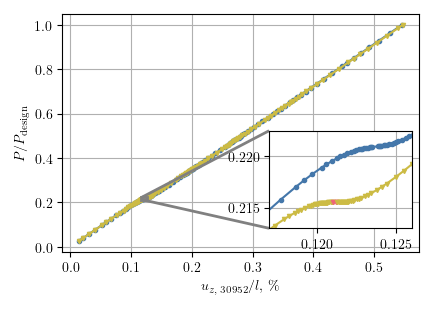

In [22]:
# Define list of op2 objects, nondimensional loads and eigenvalues for plotting
op2_list = [sol_106_op2_dict[key], sol_106_op2_unfeasible]
nondimensional_loads_list = [
    nondimensional_loads_dict[key],
    nondimensional_loads_unfeasible,
]
eigenvalues_list = [eigenvalues_dict[key], eigenvalues_unfeasible]
nondimensional_disp_list = [None, None]

# Create figure with one subplot
fig, ax = plt.subplots(figsize=(TEXTWIDTH_INCHES * 0.7, TEXTWIDTH_INCHES * 0.5))

# Iterate over the two op2 objects and plot load-displacement curves
for i, op2 in enumerate(op2_list):

    # Read displacement history from op2 object
    _, _, displacements = pynastran_utils.read_load_displacement_history_from_op2(
        op2=op2, node_ids=[max_disp_node_id]
    )

    # Nondimensionalize displacements with CRM-like Box Beam length
    first_subcase_key = next(
        iter(displacements[max_disp_node_id])
    )  # get the first subcase key from the displacements dictionary
    nondimensional_disp_list[i] = (
        displacements[max_disp_node_id][first_subcase_key][:, Z_INDEX] / L
    )  # nondimensionalize displacements with reference lengths

    # Plot load-displacement curve
    plot_utils.plot_2d_load_displacements_stability(
        ax,
        nondimensional_disp_list[i] * 100,
        nondimensional_loads_list[i],
        eigenvalues_list[i],
        MARKERS[i],
        COLORS[i],
    )  # plot load-displacement curve

# Set plot appearance
ax.set_xlabel(f"$u_{{z,\,\mathrm{{{max_disp_node_id}}}}}/l$, \%")
ax.set_ylabel("$P/P_\mathrm{design}$")
ax.grid(visible=True)

# Add legend after tight layout
plt.tight_layout()
feasible_design_line = Line2D(
    [0], [0], linestyle="-", marker=MARKERS[0], color=COLORS[0], label="Feasible design"
)
unfeasible_design_line = Line2D(
    [0],
    [0],
    linestyle="-",
    marker=MARKERS[1],
    color=COLORS[1],
    label="Unfeasible design",
)
ax.legend(
    handles=[feasible_design_line, unfeasible_design_line, unstable_line],
    loc="upper left",
    ncols=2,
    bbox_to_anchor=(-0.03, 1.25),
    frameon=False,
)

# Create zoomed inset
x1, x2 = .117, .126  # x-interval of interest for the first zoomed inset
y1, y2 = .213, .2225  # y-interval of interest for the first zoomed inset
axin = ax.inset_axes([.58, .1, 0.4, 0.41], xlim=(x1, x2), ylim=(y1, y2))
# axin.yaxis.tick_right()

# Plot in zoomed inset
for i, op2 in enumerate(op2_list):
    plot_utils.plot_2d_load_displacements_stability(
        axin,
        nondimensional_disp_list[i] * 100,
        nondimensional_loads_list[i],
        eigenvalues_list[i],
        MARKERS[i],
        COLORS[i],
    )

# Set zoomed inset appearance
axin.grid(True)
mark_inset(ax, axin, loc1=2, loc2=3, fc="none", ec="0.5", linewidth=2, zorder=2)

# Show plot and save figure
plt.show()
fig.savefig(
    os.path.join(FIGURES_DIRECTORY_PATH, "FeasibleVsUnfeasibleLoadDisplacement.pdf"),
    bbox_inches="tight",
    pad_inches=0,
)

Compare nonlinear deformation at design load.

Deformation of structure optimized under bending-only loading:


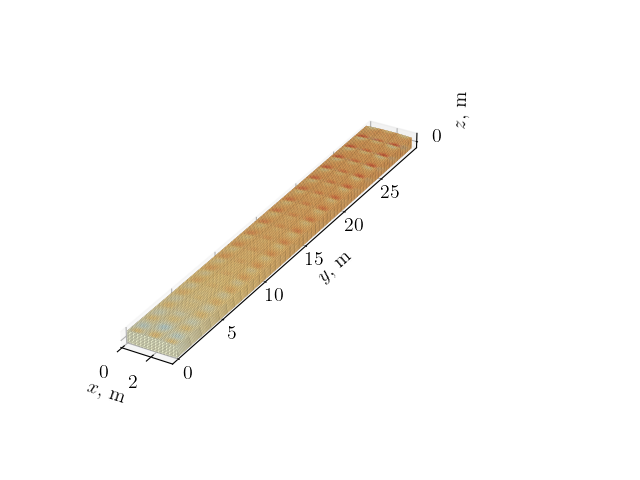

Deformation of structure optimized under bending-torsion loading:


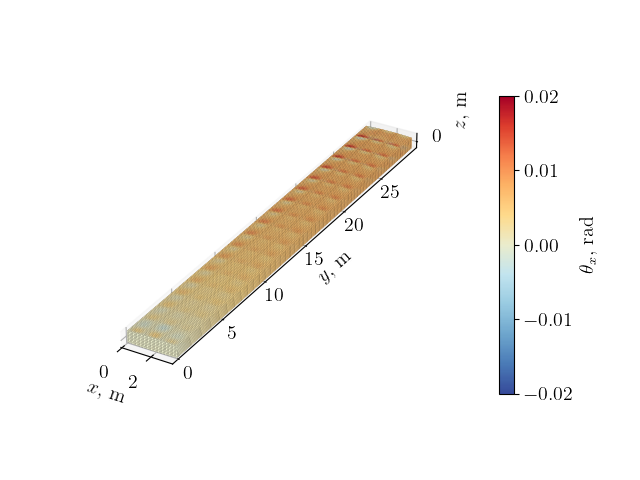

In [23]:
# Plot deformation comparison
clim = [-0.02, 0.02]  # color limits for deformation plot
label = "nonlinear-opt"
plot_deformation_comparison(nondimensional_loads_dict, sol_106_op2_dict, clim, label)